In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

from sympy import im
import torch 
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

import torchvision



In [3]:
import torchvision


print(torch.__version__)
print(torchvision.__version__)

2.12.1+cpu
0.27.1+cpu


In [4]:
SEED = 42
torch.manual_seed(SEED)

In [5]:
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_datasets = datasets.MNIST(
    root='data/',
    download=True,
    train=True,
    transform=transform
)

test_dataset = datasets.MNIST(
   root='data/',
    download=True,
    train=False,
    transform=transform
)

100.0%
100.0%
100.0%
100.0%


In [6]:
print("train dataset len: ", len(train_datasets))
print("test dataset len: ", len(test_dataset))

train dataset len:  60000
test dataset len:  10000


In [7]:
print(train_datasets)

Dataset MNIST
    Number of datapoints: 60000
    Root location: data/
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )


In [12]:
train_dataloader = DataLoader(
    dataset=train_datasets,
    shuffle=True,
    batch_size=64
)

test_dataloader = DataLoader(
    dataset=train_datasets,
    shuffle=False,
    batch_size=64
)

In [14]:
images, labels = next(iter(test_dataloader))
print("images shape: ", images.shape)
print("labels shape: ", labels.shape)
print("first 10 labels: ", labels[:10])

images shape:  torch.Size([64, 1, 28, 28])
labels shape:  torch.Size([64])
first 10 labels:  tensor([5, 0, 4, 1, 9, 2, 1, 3, 1, 4])


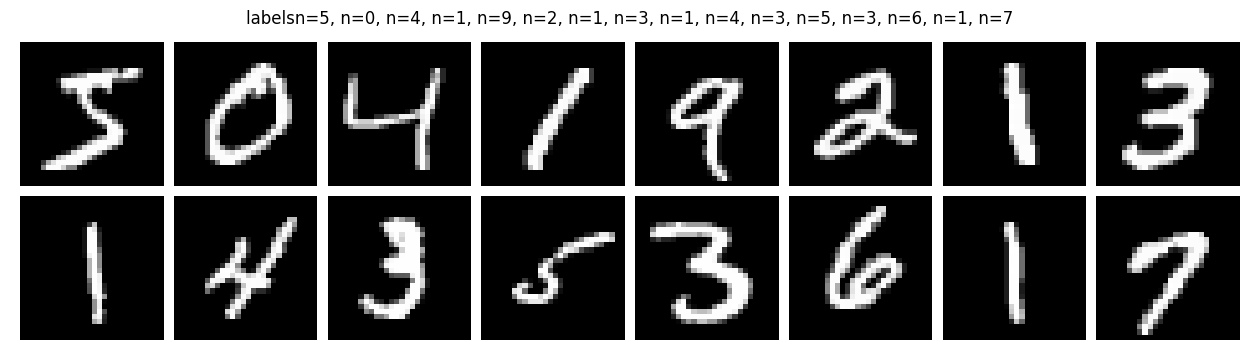

In [18]:
from turtle import title

from matplotlib.pyplot import grid


def show_mnist_sample(images, labels, n=16):
    grid = make_grid(images[:n], nrow=8, normalize=True, pad_value=1)

    plt.figure(figsize=(16, 6))
    plt.imshow(grid.permute(1, 2, 0))
    
    title = ", ".join([f"n={n}" for n in  map(str, labels[:n].tolist())])

    plt.title("labels" + title)

    plt.axis("off")

    plt.show()

show_mnist_sample(images, labels, 16)

In [27]:
model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Flatten(),
    nn.Linear(16 * 14 * 14 ,10)
).to(device="cpu")

# функція помилок
loss_fn = nn.CrossEntropyLoss()
# оптимізатор
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [29]:
def train_one_epoch(model, dataloader, loss_fn, optimizer):
    model.train()

    total_loss = 0.0
    total_items = 0
    total_correct = 0


    for images, labels in dataloader:
        optimizer.zero_grad(set_to_none=True)
        
        logits = model(images)

        loss = loss_fn(logits, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item() * len(labels)
        total_items += len(labels)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()


    return {
        "loss": total_loss/total_items,
        "accurancy": total_correct/total_items
    }

In [30]:
@torch.no_grad()
def evaluate(model, dataloader, loss_fn):
    model.eval()


    total_loss = 0.0
    total_items = 0
    total_correct = 0

    for images, labels in dataloader:

        logits = model(images)

        loss = loss_fn(logits, labels)

        total_loss += loss.items() * labels.size(0)
        total_items += labels.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()


    return {
        "loss": total_loss/total_items,
        "accurancy": total_correct/total_items
    }
     





In [33]:
def model_fit(model, train_dataloader, test_dataloader, loss_fn, optimizer, epochs=10):
    history = []    
    
    for epoch in range(1, epochs + 1):
        train_metrics = train_one_epoch(model, train_dataloader, loss_fn, optimizer)
        test_metrics = evaluate(model, test_dataloader, loss_fn)
    
        row = {
            "epoch": epoch,
            "train_loss": train_metrics['loss'],
            "train_accuracy": train_metrics['accuracy'],
            "test_loss": test_metrics['loss'],
            "test_accuracy": test_metrics['accuracy']
        }
        history.append(row)
        print(row)
        
    return pd.DataFrame(history)

In [34]:
baseline_history = model_fit(model, train_dataloader, test_dataloader, loss_fn, optimizer)
baseline_history

AttributeError: 'Tensor' object has no attribute 'items'